# 🦈 To swim or not to swim?
## Prédiction du risque d'attaque de requin

*Dédié à ma chérie qui refuse de mettre les pieds dans la mer* 🌊

---

### 👋 Présentation

Dans ce projet, j'analyse plus de **6 000 attaques de requins** recensées dans le monde
depuis le 19ème siècle pour répondre à une question simple :

> *"Est-ce qu'une attaque de requin va être fatale ou non ?"*

J'ai choisi ce sujet pour deux raisons :
- C'est un dataset original et fun — personne ne fait ça 🦈
- Ma chérie refuse d'aller à la mer à cause des requins... je vais lui prouver statistiquement qu'elle a tort (ou pas 😅)

### 📋 Étapes du projet
1. 📦 Imports
2. 🔍 Exploration des données
3. 🧹 Nettoyage des données
4. 📊 Visualisations
5. 🔧 Préparation pour le modèle
6. 🔢 Encodage
7. 📊 Matrice de corrélation
8. ✂️ Séparation des données
9. 🤖 Régression Logistique
10. 🔄 Validation Croisée
11. 📉 PCA
12. 🔗 Pipeline
13. 🌲 Random Forest + GridSearch
14. 🎲 Randomized Search
15. ⚡ Halving Search
16. 🦈 XGBoost
17. ⚖️ XGBoost équilibré
18. 🔵 K-Means Clustering
19. 📋 Conclusion

## 📦 1. Imports

J'commence par importer toutes les bibliothèques dont j'ai besoin pour ce projet.
De la manipulation de données jusqu'aux modèles de Machine Learning.

In [46]:
import pandas as pd                          # manipulation des données sous forme de tableau
import matplotlib.pyplot as plt              # création de graphiques
import seaborn as sns                        # graphiques statistiques plus avancés

from sklearn.model_selection import train_test_split   # séparer les données en train/test
from sklearn.model_selection import cross_val_predict  # évaluer un modèle par validation croisée
from sklearn.model_selection import GridSearchCV       # trouver les meilleurs hyperparamètres
from sklearn.model_selection import RandomizedSearchCV # teste aléatoirement des combinaisons
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV # recherche dichotomique
from sklearn.linear_model import LogisticRegression   # modèle de régression logistique
from sklearn.ensemble import RandomForestClassifier   # modèle Random Forest
from sklearn.preprocessing import StandardScaler      # normaliser les données
from sklearn.decomposition import PCA                 # réduire le nombre de colonnes
from sklearn.pipeline import Pipeline                 # enchaîner les étapes
from sklearn.cluster import KMeans                    # clustering non supervisé
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import silhouette_score          # qualité des clusters

from xgboost import XGBClassifier                     # modèle XGBoost (boosting)

# Désactiver les warnings de polices pour les emojis
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

## 🔍 2. Exploration des données

Avant de construire quoi que ce soit, j'explore les données pour comprendre ce que j'ai.

Le dataset vient du **Global Shark Attack File** — une base de données mondiale
qui recense les attaques de requins depuis le 19ème siècle avec :
- 🌍 Le pays et la localisation
- 🏄 L'activité de la victime (surf, baignade, plongée...)
- 🦈 L'espèce de requin
- ⚡ Le type d'attaque (provoquée, non provoquée...)
- 💀 Si l'attaque était **fatale ou non** — c'est ma cible !

In [ ]:
# Chargement du fichier CSV
# encoding='latin-1' pour gérer les caractères spéciaux
df = pd.read_csv('data/global_shark_attacks.csv', encoding='latin-1')

# Dimensions du dataset
print(f"Le dataset contient {df.shape[0]} attaques et {df.shape[1]} colonnes")

# Aperçu des 5 premières lignes
df.head()

Le dataset contient 25723 attaques et 24 colonnes


,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,...,Species,Investigator or Source,pdf,href formula,href,Case Number.1,Case Number.2,original order,Unnamed: 22,Unnamed: 23
0,2018.06.25,25-Jun-2018,2018.0,Boating,USA,California,"Oceanside, San Diego County",Paddling,Julie Wolfe,F,...,White shark,"R. Collier, GSAF",2018.06.25-Wolfe.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2018.06.25,2018.06.25,6303.0,NaN,NaN
1,2018.06.18,18-Jun-2018,2018.0,Unprovoked,USA,Georgia,"St. Simon Island, Glynn County",Standing,Adyson McNeely,F,...,NaN,"K.McMurray, TrackingSharks.com",2018.06.18-McNeely.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2018.06.18,2018.06.18,6302.0,NaN,NaN
2,2018.06.09,09-Jun-2018,2018.0,Invalid,USA,Hawaii,"Habush, Oahu",Surfing,John Denges,M,...,NaN,"K.McMurray, TrackingSharks.com",2018.06.09-Denges.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2018.06.09,2018.06.09,6301.0,NaN,NaN
3,2018.06.08,08-Jun-2018,2018.0,Unprovoked,AUSTRALIA,New South Wales,Arrawarra Headland,Surfing,male,M,...,2 m shark,"B. Myatt, GSAF",2018.06.08-Arrawarra.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2018.06.08,2018.06.08,6300.0,NaN,NaN
4,2018.06.04,04-Jun-2018,2018.0,Provoked,MEXICO,Colima,La Ticla,Free diving,Gustavo Ramos,M,...,"Tiger shark, 3m",A .Kipper,2018.06.04-Ramos.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2018.06.04,2018.06.04,6299.0,NaN,NaN


In [48]:
# Vérification des valeurs manquantes par colonne
print("Valeurs manquantes par colonne :")
df.isna().sum()

Valeurs manquantes par colonne :


Case Number               17021
Date                      19421
Year                      19423
Type                      19425
Country                   19471
Area                      19876
Location                  19961
Activity                  19965
Name                      19631
Sex                       19986
Age                       22252
Injury                    19449
Fatal (Y/N)               19960
Time                      22775
Species                   22259
Investigator or Source    19438
pdf                       19421
href formula              19422
href                      19421
Case Number.1             19421
Case Number.2             19421
original order            19414
Unnamed: 22               25722
Unnamed: 23               25721
dtype: int64

### 📌 Ce que j'observe

Le dataset contient **25 723 lignes** mais enormément de valeurs manquantes !
C'est normal pour des données historiques depuis le 19ème siècle —
les informations n'étaient pas toujours bien documentées à l'époque.

> 💡 Je vais devoir faire un nettoyage sérieux pour garder uniquement les lignes exploitables.

In [49]:
# Résumé technique : types de données et valeurs non-nulles
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25723 entries, 0 to 25722
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Case Number             8702 non-null   str    
 1   Date                    6302 non-null   str    
 2   Year                    6300 non-null   float64
 3   Type                    6298 non-null   str    
 4   Country                 6252 non-null   str    
 5   Area                    5847 non-null   str    
 6   Location                5762 non-null   str    
 7   Activity                5758 non-null   str    
 8   Name                    6092 non-null   str    
 9   Sex                     5737 non-null   str    
 10  Age                     3471 non-null   str    
 11  Injury                  6274 non-null   str    
 12  Fatal (Y/N)             5763 non-null   str    
 13  Time                    2948 non-null   str    
 14  Species                 3464 non-null   str    
 

In [50]:
# Statistiques descriptives : moyenne, min, max, écart-type...
df.describe()

,Year,original order
count,6300.000000,6309.000000
mean,1927.272381,3155.999683
std,281.116308,1821.396206
min,0.000000,2.000000
25%,1942.000000,1579.000000
50%,1977.000000,3156.000000
75%,2005.000000,4733.000000
max,2018.000000,6310.000000


## 🧹 3. Nettoyage des données

Le dataset brut contient beaucoup de colonnes inutiles que je vais supprimer :

| Colonne | Raison de suppression |
|---|---|
| `Case Number`, `Case Number.1`, `Case Number.2` | Simple identifiant — n'apporte aucune info au modèle |
| `Name` | Nom de la victime — information personnelle inutile |
| `pdf`, `href`, `href formula` | Liens vers les sources — inutiles pour la prédiction |
| `Unnamed: 22`, `Unnamed: 23` | Colonnes complètement vides |
| `Investigator or Source` | Source de l'information — inutile pour le modèle |
| `original order` | Ordre d'insertion dans la base — inutile |

Je vais ensuite :
1. **Supprimer les lignes** sans information essentielle
2. **Nettoyer la colonne cible** Fatal (Y/N)

In [51]:
# Je supprime les colonnes qui n'apportent aucune information utile
df.drop(columns=[
    'Case Number', 'Case Number.1', 'Case Number.2',
    'Name', 'pdf', 'href formula', 'href',
    'Unnamed: 22', 'Unnamed: 23',
    'Investigator or Source', 'original order'
], inplace=True)

print(f"Colonnes restantes : {df.shape[1]}")
print(df.columns.tolist())

Colonnes restantes : 13
['Date', 'Year', 'Type', 'Country', 'Area', 'Location', 'Activity', 'Sex ', 'Age', 'Injury', 'Fatal (Y/N)', 'Time', 'Species ']


In [52]:
# Je garde uniquement les lignes où les colonnes essentielles sont renseignées
df.dropna(subset=['Fatal (Y/N)', 'Activity', 'Country'], inplace=True)

# Nettoyage de la colonne cible : je garde uniquement Y et N
df = df[df['Fatal (Y/N)'].isin(['Y', 'N'])]

print(f"Lignes restantes après nettoyage : {len(df)}")
print(f"\nRépartition de la cible :")
print(df['Fatal (Y/N)'].value_counts())

Lignes restantes après nettoyage : 5263

Répartition de la cible :
Fatal (Y/N)
N    4003
Y    1260
Name: count, dtype: int64


### 📌 Ce que j'observe

Après nettoyage il me reste **5 263 lignes** exploitables.

Je remarque déjà que le dataset est **déséquilibré** :
- 4 003 attaques non fatales (76%)
- 1 260 attaques fatales (24%)

> ⚠️ Ce déséquilibre va poser problème lors de l'entraînement —
> le modèle aura tendance à toujours prédire "Non Fatal".


## 📊 4. Visualisations

Avant de modéliser, je visualise les données pour mieux comprendre
quels facteurs influencent la fatalité d'une attaque.

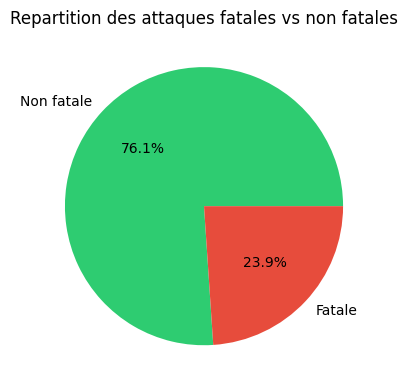

In [53]:
# Répartition des attaques fatales vs non fatales
plt.figure(figsize=(6, 4))
df['Fatal (Y/N)'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                       colors=['#2ecc71', '#e74c3c'],
                                       labels=['Non fatale', 'Fatale'])
plt.title("Repartition des attaques fatales vs non fatales")
plt.ylabel("")
plt.tight_layout()
plt.show()

### 📌 Ce que j'observe

- **76.1%** des attaques ne sont **pas fatales** 🟢
- **23.9%** des attaques sont **fatales** 🔴

> 💡 Bonne nouvelle pour ma chérie : **3 attaques sur 4 ne sont pas mortelles !**

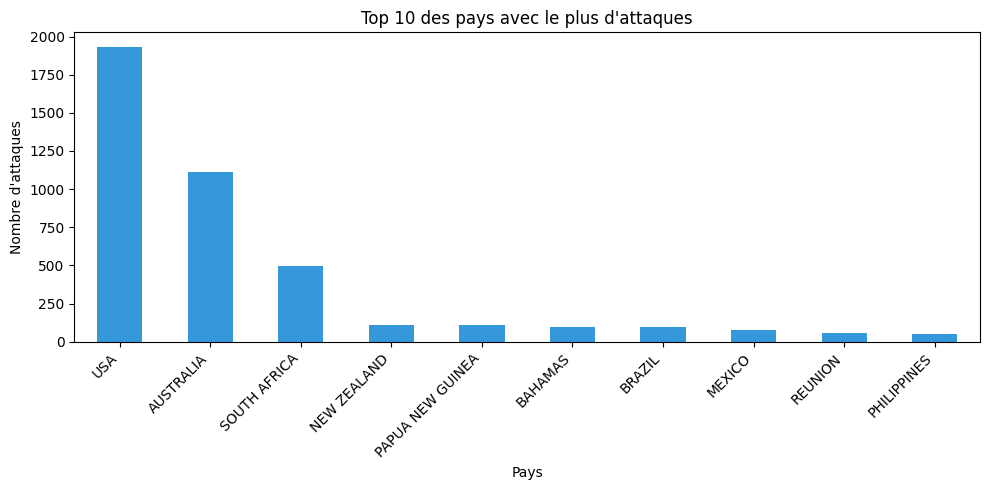

In [54]:
# Top 10 des pays avec le plus d'attaques
plt.figure(figsize=(10, 5))
df['Country'].value_counts().head(10).plot(kind='bar', color='#3498db')
plt.title("Top 10 des pays avec le plus d'attaques")
plt.xlabel("Pays")
plt.ylabel("Nombre d'attaques")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 📌 Ce que j'observe

Les USA dominent largement avec près de **2 000 attaques** recensées,
suivis de l'Australie (**~1 100**) et l'Afrique du Sud (**~500**).

> 💡 Conseil à ma chérie : **éviter les plages américaines et australiennes !**
> La Réunion est aussi dans le top 10 — à noter pour les vacances 😅

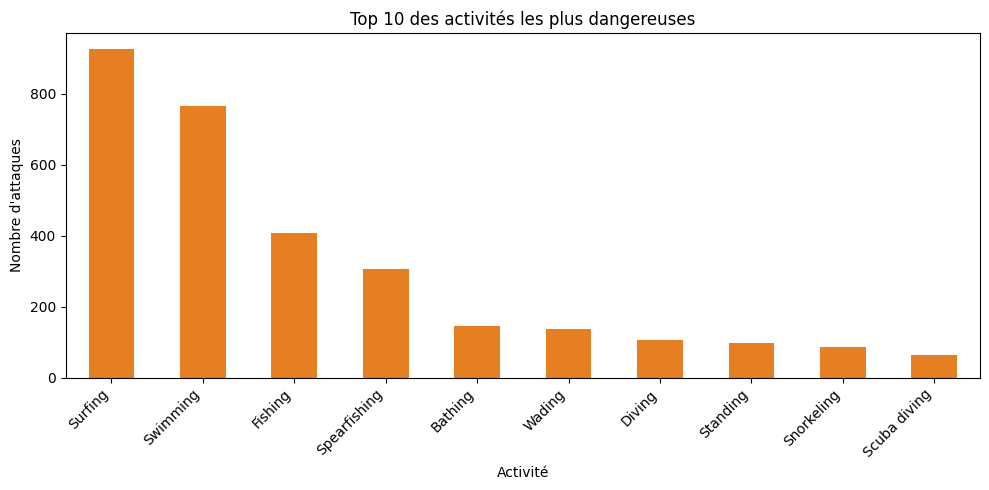

In [55]:
# Top 10 des activités les plus dangereuses
plt.figure(figsize=(10, 5))
df['Activity'].value_counts().head(10).plot(kind='bar', color='#e67e22')
plt.title("Top 10 des activités les plus dangereuses")
plt.xlabel("Activité")
plt.ylabel("Nombre d'attaques")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 📌 Ce que j'observe

Les activités les plus touchées :
- 🏄 **Surf** (Surfing) : ~930 attaques — le plus dangereux !
- 🏊 **Baignade** (Swimming) : ~770 attaques
- 🎣 **Pêche** (Fishing) : ~410 attaques
- 🤿 **Pêche sous-marine** (Spearfishing) : ~310 attaques

> 💡 Conseil à ma chérie : **ne pas surfer** est déjà une très bonne décision !
> La simple baignade est en 2ème position...
> mais rappelons que 76% des attaques ne sont pas fatales 😅

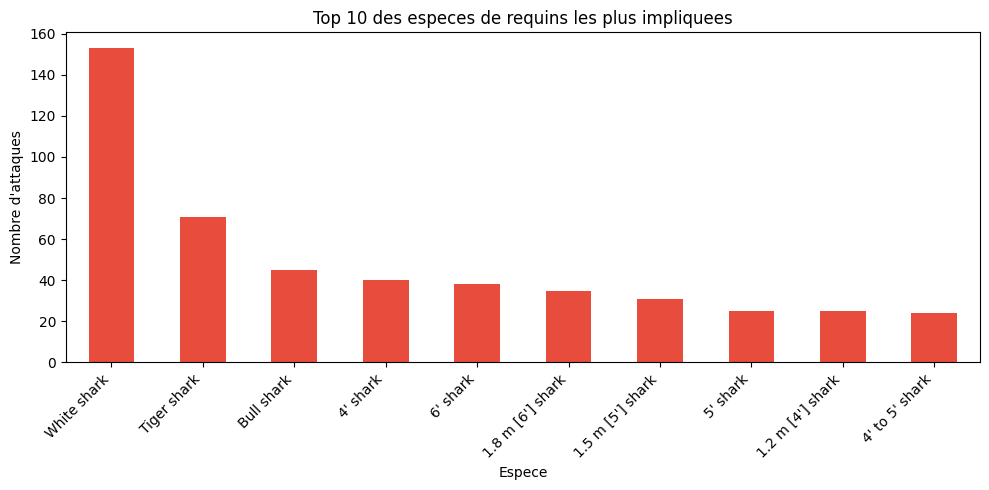

In [56]:
# Top 10 des espèces de requins les plus impliquées
plt.figure(figsize=(10, 5))
df['Species '].value_counts().head(10).plot(kind='bar', color='#e74c3c')
plt.title("Top 10 des especes de requins les plus impliquees")
plt.xlabel("Espece")
plt.ylabel("Nombre d'attaques")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 📌 Ce que j'observe

- 🦈 **Grand requin blanc** (White shark) : ~155 attaques — le plus redouté !
- 🦈 **Requin tigre** (Tiger shark) : ~70 attaques
- 🦈 **Requin bouledogue** (Bull shark) : ~45 attaques

> ⚠️ Beaucoup d'entrées indiquent juste la taille du requin car l'espèce n'a pas été identifiée.<br>
> 💡 Ma chérie a donc statistiquement raison de se méfier du grand requin blanc !
> Mais il est **extrêmement rare** d'en croiser un à la plage 🦈

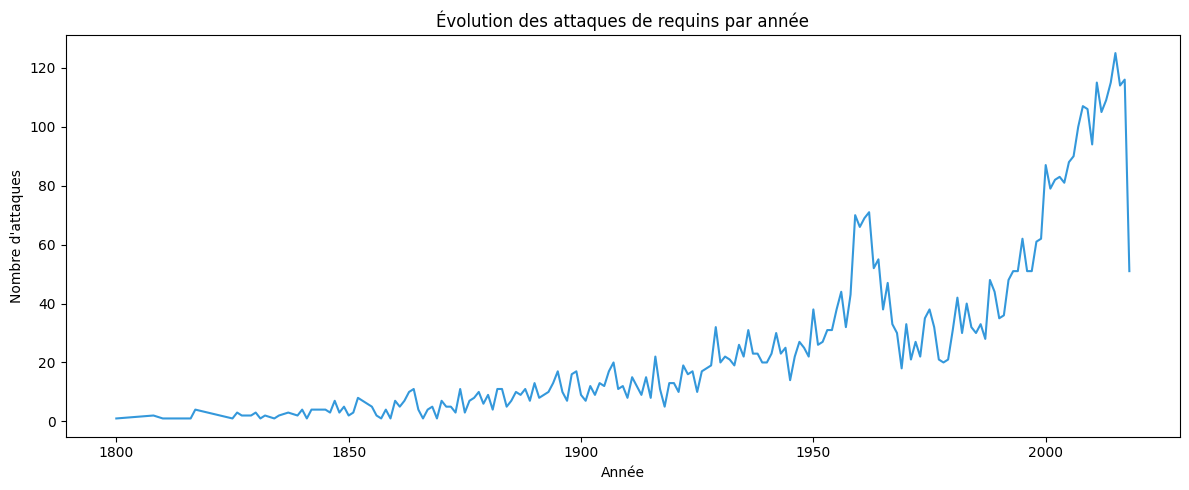

In [57]:
# Évolution du nombre d'attaques par année
df_year = df[(df['Year'] >= 1800) & (df['Year'] <= 2023)]

plt.figure(figsize=(12, 5))
df_year['Year'].value_counts().sort_index().plot(kind='line', color='#3498db')
plt.title("Évolution des attaques de requins par année")
plt.xlabel("Année")
plt.ylabel("Nombre d'attaques")
plt.tight_layout()
plt.show()

### 📌 Ce que j'observe

Le nombre d'attaques a **explosé depuis les années 2000** !

- Avant 1900 : moins de **10 attaques** recensées par an
- Années 1950-1960 : montée progressive jusqu'à **~70 attaques**
- Années 2000-2020 : pic à **~125 attaques** par an

> ⚠️ Cette hausse ne signifie pas que les requins sont plus agressifs !
> Elle s'explique par un meilleur recensement et plus de gens en mer.
> 😷 La chute après 2020 est probablement due au **Covid-19** qui a vidé les plages !

## 🔧 5. Préparation des données pour le modèle

Je prépare maintenant les données pour le modèle ML :
1. **Garder uniquement les colonnes utiles** pour la prédiction
2. **Nettoyer les valeurs** de chaque colonne
3. **Encoder la cible** : Y → 1 (fatal) et N → 0 (non fatal)

In [58]:
# Je garde uniquement les colonnes utiles pour prédire la fatalité
df = df[['Type', 'Country', 'Activity', 'Sex ', 'Age', 'Species ', 'Year', 'Fatal (Y/N)']]

# Encodage de la cible : Y = 1 (fatal) et N = 0 (non fatal)
df['Fatal (Y/N)'] = df['Fatal (Y/N)'].map({'Y': 1, 'N': 0})

print(f"Colonnes gardées : {df.columns.tolist()}")
print(f"Lignes restantes : {len(df)}")
df.head()

Colonnes gardées : ['Type', 'Country', 'Activity', 'Sex ', 'Age', 'Species ', 'Year', 'Fatal (Y/N)']
Lignes restantes : 5263


,Type,Country,Activity,Sex,Age,Species,Year,Fatal (Y/N)
0,Boating,USA,Paddling,F,57,White shark,2018.0,0
1,Unprovoked,USA,Standing,F,11,NaN,2018.0,0
2,Invalid,USA,Surfing,M,48,NaN,2018.0,0
3,Unprovoked,AUSTRALIA,Surfing,M,NaN,2 m shark,2018.0,0
4,Provoked,MEXICO,Free diving,M,NaN,"Tiger shark, 3m",2018.0,0


In [59]:
# La colonne Age contient des valeurs textuelles bizarres
# Je convertis en nombre et remplace les manquants par la médiane
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age'] = df['Age'].fillna(df['Age'].median())

print(f"Age médian : {df['Age'].median()} ans")
print(f"Age moyen : {df['Age'].mean():.1f} ans")

Age médian : 24.0 ans
Age moyen : 25.9 ans


### 📌 Ce que j'observe

- **Age médian : 24 ans** — les victimes sont majoritairement de jeunes adultes
- **Age moyen : 25.9 ans** — cohérent avec les activités à risque

> 💡 Les jeunes hommes qui surfent sont clairement le profil le plus à risque !

In [60]:
# Nettoyage de la colonne Sex
df['Sex '] = df['Sex '].str.strip()
df['Sex '] = df['Sex '].where(df['Sex '].isin(['M', 'F']), other=None)
df['Sex '] = df['Sex '].fillna(df['Sex '].mode()[0])

print("Répartition par sexe :")
print(df['Sex '].value_counts())

Répartition par sexe :
Sex 
M    4729
F     534
Name: count, dtype: int64


### 📌 Ce que j'observe

- **Hommes : 4 729** attaques (90%)
- **Femmes : 534** attaques (10%)

> 😄 Les hommes sont **9 fois plus attaqués** que les femmes !<br>
> Autre bonne raison pour ma chérie de rester sur la plage 😄

In [61]:
# Suppression des lignes avec des valeurs manquantes restantes
print(f"Lignes avant : {len(df)}")
df = df.dropna(subset=['Type', 'Country', 'Activity', 'Species '])
print(f"Lignes après : {len(df)}")

Lignes avant : 5263
Lignes après : 2811


### 📌 Ce que j'observe

Je passe de **5 263 à 2 811 lignes** après suppression des valeurs manquantes.

La perte principale vient de **Species** — beaucoup d'attaques n'ont pas eu
d'identification de l'espèce de requin impliquée.

> ✅ 2 811 lignes restent suffisantes pour entraîner mes modèles ML.

## 🔢 6. Encodage des colonnes textuelles

Les modèles ML ne comprennent que les nombres.
Je transforme les colonnes textuelles en chiffres avec `pd.factorize`.

In [62]:
# Renommage des colonnes pour supprimer les espaces
df.columns = df.columns.str.strip()

# Sélection des colonnes non numériques
non_numeric_cols = df.select_dtypes(include=['str']).columns

# pd.factorize remplace chaque valeur unique par un entier
for col in non_numeric_cols:
    df[col] = pd.factorize(df[col], sort=True)[0]

print("Encodage terminé !")
df.head()

Encodage terminé !


,Type,Country,Activity,Sex,Age,Species,Year,Fatal (Y/N)
0,1,118,377,0,57.0,1188,2018.0,0
3,6,6,580,1,24.0,231,2018.0,0
4,3,62,247,1,24.0,1133,2018.0,0
6,6,12,602,1,18.0,1068,2018.0,1
7,6,118,163,1,52.0,788,2018.0,0


## 📊 7. Matrice de corrélation

Je visualise les liens entre les colonnes pour identifier
lesquelles sont les plus liées à la fatalité d'une attaque.

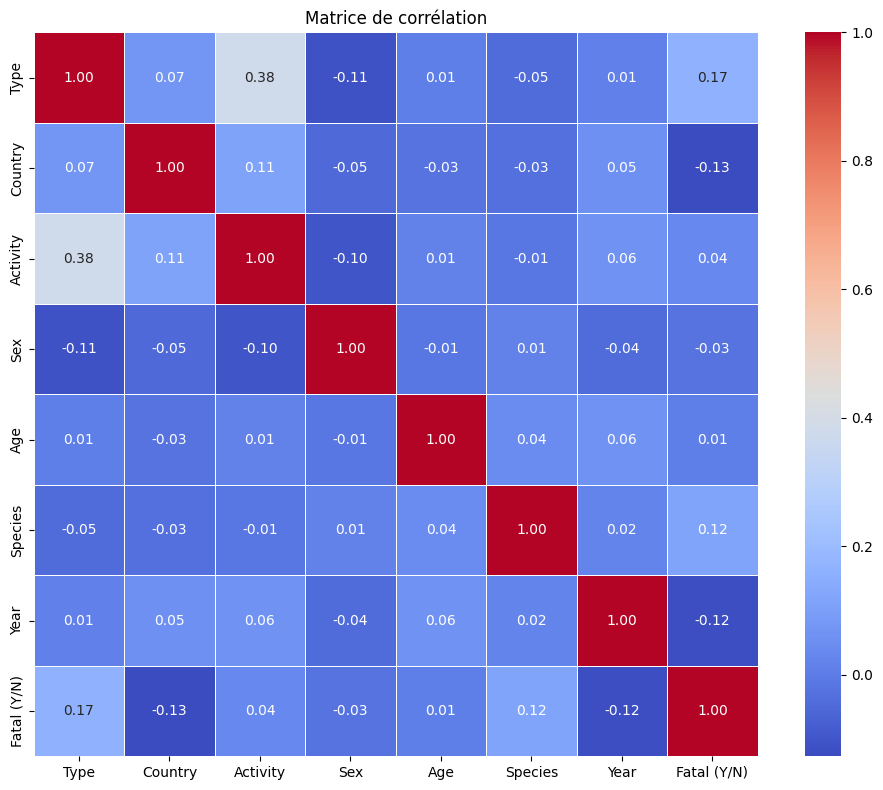

In [63]:
# Calcul et affichage de la matrice de corrélation
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

### 📌 Ce que j'observe

| Colonne | Corrélation | Interprétation |
|---|---|---|
| `Type` | **0.17** | Le type d'attaque influence la fatalité |
| `Species` | **0.12** | L'espèce de requin a un impact |
| `Country` | **-0.13** | Certains pays ont plus de décès |
| `Year` | **-0.12** | Les attaques récentes sont moins fatales |

<br>

> 💡 Les corrélations sont globalement **faibles** — aucune colonne
> n'explique à elle seule la fatalité.

> 📉 `Year` est négatif : les attaques récentes sont **moins mortelles**
> grâce aux progrès médicaux et aux secours plus rapides.

## ✂️ 8. Séparation des données

Je sépare les données en :
- **X** : les caractéristiques (ce que le modèle utilise pour prédire)
- **y** : la cible (l'attaque est-elle fatale ?)

Puis je divise en **80% pour entraîner** et **20% pour tester**.

In [64]:
# X = toutes les colonnes sauf la cible
X = df.drop(columns=['Fatal (Y/N)'])

# y = uniquement la colonne cible (0 = non fatal, 1 = fatal)
y = df['Fatal (Y/N)']

# Séparation 80% / 20%
# stratify=y : garantit la même proportion d'attaques fatales dans chaque partie
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Taille entraînement : {X_train.shape[0]} lignes")
print(f"Taille test         : {X_test.shape[0]} lignes")
print(f"\nRépartition de la cible dans y_train :")
print(y_train.value_counts())

Taille entraînement : 2248 lignes
Taille test         : 563 lignes

Répartition de la cible dans y_train :
Fatal (Y/N)
0    1928
1     320
Name: count, dtype: int64


### 📌 Ce que j'observe

- **2 248 lignes** pour entraîner le modèle
- **563 lignes** pour le tester

Le dataset est **déséquilibré** :
- 1 928 attaques non fatales (86%)
- 320 attaques fatales (14%)



## 🤖 9. Régression Logistique

Je commence avec la **Régression Logistique** — un modèle simple et rapide
qui calcule la probabilité qu'une attaque soit fatale.

Je normalise d'abord les données pour que toutes les colonnes soient sur la même échelle.

Régression Logistique - Résultats
Accuracy : 0.8650088809946714
              precision    recall  f1-score   support

   Non Fatal       0.86      1.00      0.93       483
       Fatal       1.00      0.05      0.10        80

    accuracy                           0.87       563
   macro avg       0.93      0.53      0.51       563
weighted avg       0.88      0.87      0.81       563



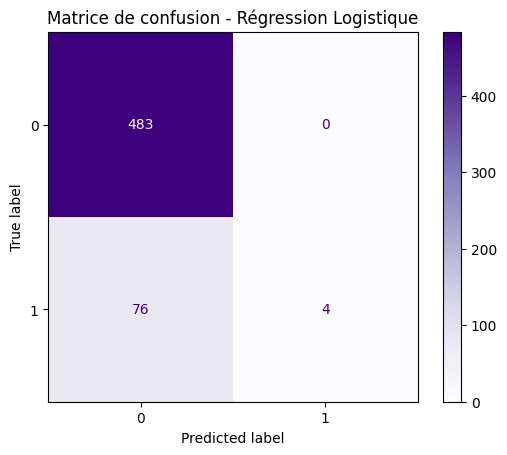

In [65]:
# StandardScaler normalise les données (moyenne=0, écart-type=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # apprend + transforme sur train
X_test_scaled  = scaler.transform(X_test)        # transforme seulement sur test

# Création et entraînement du modèle
lr_model = LogisticRegression(random_state=0, max_iter=5000)
lr_model.fit(X_train_scaled, y_train)

# Prédictions et résultats
y_pred_lr = lr_model.predict(X_test_scaled)
print("Régression Logistique - Résultats")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, target_names=["Non Fatal", "Fatal"]))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap="Purples")
plt.title("Matrice de confusion - Régression Logistique")
plt.show()

### 📌 Ce que j'observe

- **Accuracy globale : 87%** — semble bien mais c'est trompeur !

| Métrique | Non Fatal | Fatal |
|---|---|---|
| Recall | 1.00 | **0.05** |
| F1-score | 0.93 | **0.10** |

<br>

> ⚠️ Mon modèle détecte **seulement 5% des attaques fatales** !
> C'est le problème classique du **dataset déséquilibré**.

## 🔄 10. Validation Croisée

La **validation croisée** me permet de vérifier que mon modèle est fiable.

Je divise X_train en 5 blocs. Le modèle s'entraîne sur 4 blocs
et est testé sur le 5ème, en tournant 5 fois.
Ainsi chaque donnée a été testée exactement une fois.

Validation Croisée - Régression Logistique
              precision    recall  f1-score   support

   Non Fatal       0.86      1.00      0.92      1928
       Fatal       0.40      0.02      0.04       320

    accuracy                           0.86      2248
   macro avg       0.63      0.51      0.48      2248
weighted avg       0.79      0.86      0.80      2248



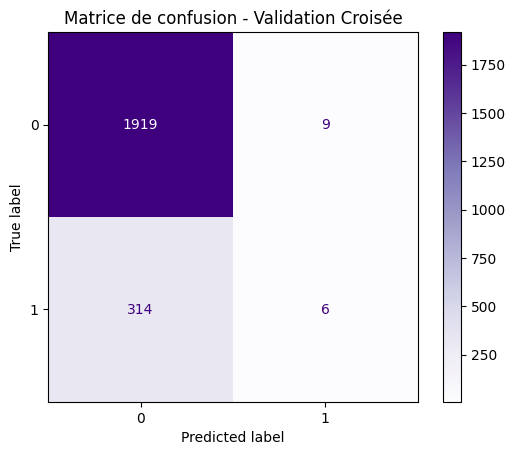

In [66]:
# cv=5 : 5 blocs de validation (folds)
y_pred_cv = cross_val_predict(lr_model, X_train_scaled, y_train, cv=5)

print("Validation Croisée - Régression Logistique")
print(classification_report(y_train, y_pred_cv, target_names=["Non Fatal", "Fatal"]))

ConfusionMatrixDisplay.from_predictions(y_train, y_pred_cv, cmap="Purples")
plt.title("Matrice de confusion - Validation Croisée")
plt.show()

### 📌 Ce que j'observe

La validation croisée confirme le problème :

| Métrique | Non Fatal | Fatal |
|---|---|---|
| Recall | 1.00 | **0.02** |
| F1-score | 0.92 | **0.04** |

<br>

> ⚠️ La régression logistique est clairement **insuffisante**.
> Je passe à des modèles plus puissants !

## 📉 11. Réduction de dimensions avec PCA

La **PCA** réduit le nombre de colonnes en gardant uniquement
les directions où les données varient le plus.

Je conserve 95% de l'information avec moins de colonnes.

In [67]:
# n_components=0.95 : je garde 95% de la variance
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"Dimensions avant PCA : {X_train_scaled.shape[1]} colonnes")
print(f"Dimensions après PCA  : {X_train_pca.shape[1]} composantes")
print(f"Variance conservée    : {pca.explained_variance_ratio_.sum():.2%}")

Dimensions avant PCA : 7 colonnes
Dimensions après PCA  : 7 composantes
Variance conservée    : 100.00%


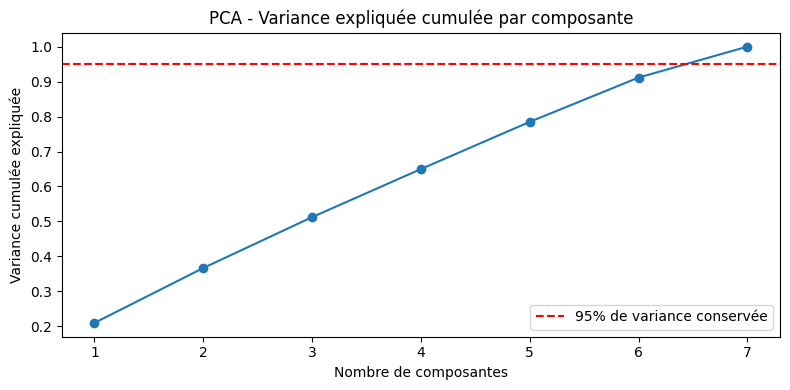

In [68]:
# Graphique de la variance expliquée cumulée
plt.figure(figsize=(8, 4))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_.cumsum(),
    marker='o'
)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% de variance conservée')
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance cumulée expliquée')
plt.title('PCA - Variance expliquée cumulée par composante')
plt.legend()
plt.tight_layout()
plt.show()

### 📌 Ce que j'observe

La PCA garde **7 composantes sur 7** — toutes mes colonnes apportent
une information unique, il n'y a pas de redondance.

> 💡 La courbe monte progressivement et régulièrement — chaque colonne
> est indépendante des autres. Je la garde dans le Pipeline pour être complet.

## 🔗 12. Pipeline

Le **Pipeline** enchaîne automatiquement mes étapes de prétraitement
et le modèle en un seul objet.

Plus besoin de transformer les données manuellement —
je donne directement `X_train` et le Pipeline gère le reste !

In [69]:
# Mon Pipeline enchaîne dans l'ordre :
# étape 1 : normaliser → étape 2 : réduire les dimensions → étape 3 : modèle
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=0.95)),
    ('model',  RandomForestClassifier(random_state=0))
])

## 🌲 13. Random Forest optimisé avec GridSearch

Le **Random Forest** combine plusieurs arbres de décision pour être plus précis.

J'utilise le **GridSearch** pour tester automatiquement toutes les combinaisons
de paramètres possibles et garder la meilleure configuration.

Meilleurs paramètres trouvés : {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 300}

Random Forest optimisé - Résultats
Accuracy : 0.8596802841918295
              precision    recall  f1-score   support

   Non Fatal       0.87      0.99      0.92       483
       Fatal       0.54      0.09      0.15        80

    accuracy                           0.86       563
   macro avg       0.70      0.54      0.54       563
weighted avg       0.82      0.86      0.81       563



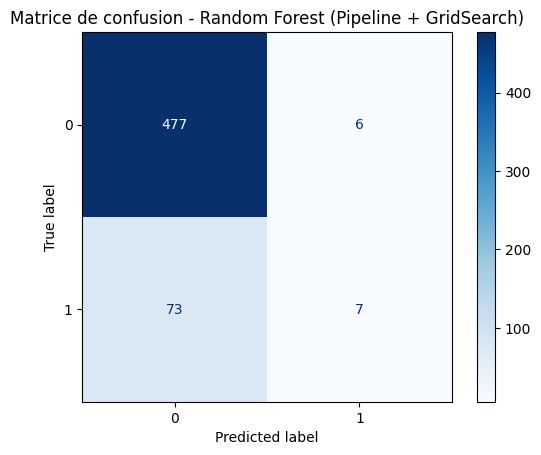

In [70]:
# Grille des paramètres à tester : 2 x 3 x 2 = 12 combinaisons
param_grid = {
    'model__n_estimators':      [100, 300],
    'model__max_depth':         [10, 20, None],
    'model__min_samples_split': [2, 5],
}

grid_search = GridSearchCV(pipeline, param_grid, cv=3, n_jobs=-1, refit=True)
grid_search.fit(X_train, y_train)

print("Meilleurs paramètres trouvés :", grid_search.best_params_)

y_pred_rf = grid_search.predict(X_test)
print("\nRandom Forest optimisé - Résultats")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=["Non Fatal", "Fatal"]))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap="Blues")
plt.title("Matrice de confusion - Random Forest (Pipeline + GridSearch)")
plt.show()

### 📌 Ce que j'observe

| Métrique | Régression Logistique | Random Forest |
|---|---|---|
| Accuracy | 0.87 | 0.86 |
| Recall Fatal | 0.05 | **0.09** |
| F1 Fatal | 0.10 | **0.15** |

<br>

> ⚠️ Le Random Forest est légèrement meilleur mais le recall reste faible.
> Je vais essayer le Randomized Search et le Halving !

## 🎲 14. Randomized Search

Alternative au GridSearch : au lieu de tester **toutes** les combinaisons,
il en tire **aléatoirement** un nombre défini.

Avantage : beaucoup plus rapide sur de grandes grilles de paramètres !

Meilleurs paramètres (Randomized Search) : {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__max_depth': 10}

Random Forest - Randomized Search - Résultats
Accuracy : 0.8614564831261101
              precision    recall  f1-score   support

   Non Fatal       0.87      0.99      0.92       483
       Fatal       0.58      0.09      0.15        80

    accuracy                           0.86       563
   macro avg       0.73      0.54      0.54       563
weighted avg       0.83      0.86      0.81       563



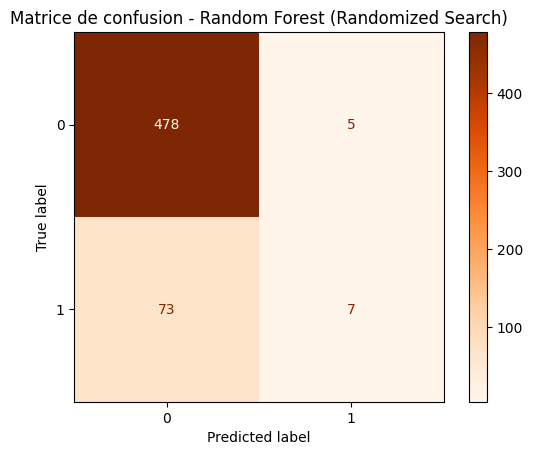

In [71]:
# Grille plus large — Randomized Search ne teste que 10 combinaisons
param_grid_random = {
    'model__n_estimators':      [100, 200, 300, 500],
    'model__max_depth':         [10, 20, 30, None],
    'model__min_samples_split': [2, 5, 10],
}

random_search = RandomizedSearchCV(
    pipeline, param_grid_random,
    n_iter=10, cv=3, n_jobs=-1, random_state=0, refit=True
)
random_search.fit(X_train, y_train)

print("Meilleurs paramètres (Randomized Search) :", random_search.best_params_)

y_pred_random = random_search.predict(X_test)
print("\nRandom Forest - Randomized Search - Résultats")
print("Accuracy :", accuracy_score(y_test, y_pred_random))
print(classification_report(y_test, y_pred_random, target_names=["Non Fatal", "Fatal"]))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_random, cmap="Oranges")
plt.title("Matrice de confusion - Random Forest (Randomized Search)")
plt.show()

### 📌 Ce que j'observe

| Méthode | Accuracy | Recall Fatal | F1 Fatal |
|---|---|---|---|
| GridSearch | 0.86 | 0.09 | 0.15 |
| **Randomized Search** | **0.86** | **0.09** | **0.15** |

<br>

> 💡 Résultats similaires au GridSearch mais beaucoup plus rapide !
> Sur une très grande grille, la différence de vitesse serait énorme.

## ⚡ 15. Halving Search

Méthode dichotomique : commence avec **peu de données** et élimine
progressivement les mauvais candidats au fur et à mesure.

C'est la méthode la plus rapide des trois !

Meilleurs paramètres (Halving) : {'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 300}

Random Forest - Halving - Résultats
Accuracy : 0.8561278863232682
              precision    recall  f1-score   support

   Non Fatal       0.87      0.98      0.92       483
       Fatal       0.47      0.11      0.18        80

    accuracy                           0.86       563
   macro avg       0.67      0.55      0.55       563
weighted avg       0.81      0.86      0.82       563



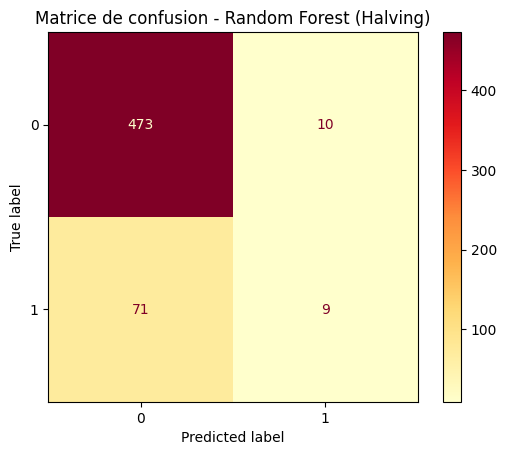

In [72]:
# HalvingGridSearchCV est encore expérimental dans sklearn
halving_search = HalvingGridSearchCV(
    pipeline, param_grid,
    cv=3, n_jobs=-1, random_state=0, refit=True
)
halving_search.fit(X_train, y_train)

print("Meilleurs paramètres (Halving) :", halving_search.best_params_)

y_pred_halving = halving_search.predict(X_test)
print("\nRandom Forest - Halving - Résultats")
print("Accuracy :", accuracy_score(y_test, y_pred_halving))
print(classification_report(y_test, y_pred_halving, target_names=["Non Fatal", "Fatal"]))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_halving, cmap="YlOrRd")
plt.title("Matrice de confusion - Random Forest (Halving)")
plt.show()

### 📌 Ce que j'observe

| Méthode | Accuracy | Recall Fatal | F1 Fatal | Vitesse |
|---|---|---|---|---|
| GridSearch | 0.86 | 0.09 | 0.15 | 🐢 Lent |
| Randomized Search | 0.86 | 0.09 | 0.15 | 🐇 Rapide |
| **Halving** | **0.86** | **0.11** | **0.18** | **⚡ Très rapide** |

<br>

> 💡 Le Halving donne le **meilleur recall Fatal** (0.11) tout en étant
> le plus rapide — c'est ma méthode préférée !

## 🦈 16. XGBoost

**XGBoost** est un modèle de boosting : chaque arbre apprend des erreurs du précédent.
C'est généralement le modèle le plus performant sur des données déséquilibrées.

XGBoost - Résultats
Accuracy : 0.8436944937833037
              precision    recall  f1-score   support

   Non Fatal       0.87      0.96      0.91       483
       Fatal       0.38      0.16      0.23        80

    accuracy                           0.84       563
   macro avg       0.63      0.56      0.57       563
weighted avg       0.80      0.84      0.82       563



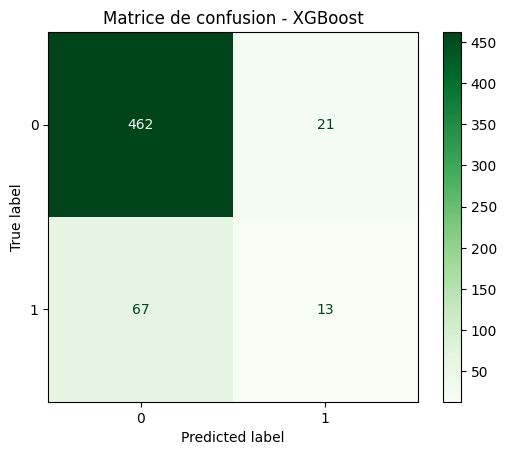

In [73]:
# eval_metric="logloss" : mesure d'erreur adaptée à la classification binaire
xgb_model = XGBClassifier(random_state=0, eval_metric="logloss")
xgb_model.fit(X_train_pca, y_train)

y_pred_xgb = xgb_model.predict(X_test_pca)

print("XGBoost - Résultats")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb, target_names=["Non Fatal", "Fatal"]))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, cmap="Greens")
plt.title("Matrice de confusion - XGBoost")
plt.show()

### 📌 Ce que j'observe

| Modèle | Accuracy | Recall Fatal | F1 Fatal |
|---|---|---|---|
| Régression Logistique | 0.87 | 0.05 | 0.10 |
| Random Forest (Halving) | 0.86 | 0.11 | 0.18 |
| **XGBoost** | **0.84** | **0.16** | **0.23** |

<br>

> 💡 XGBoost détecte mieux les attaques fatales (recall 0.16 vs 0.05) !
> Mais je peux encore améliorer avec `scale_pos_weight`.

## ⚖️ 17. XGBoost équilibré

Mon dataset est déséquilibré : 86% non fatal vs 14% fatal.
J'utilise `scale_pos_weight` pour donner plus de poids à la classe minoritaire
et améliorer la détection des attaques fatales.

scale_pos_weight : 6.03

XGBoost équilibré - Résultats
Accuracy : 0.8046181172291297
              precision    recall  f1-score   support

   Non Fatal       0.88      0.90      0.89       483
       Fatal       0.29      0.25      0.27        80

    accuracy                           0.80       563
   macro avg       0.58      0.57      0.58       563
weighted avg       0.79      0.80      0.80       563



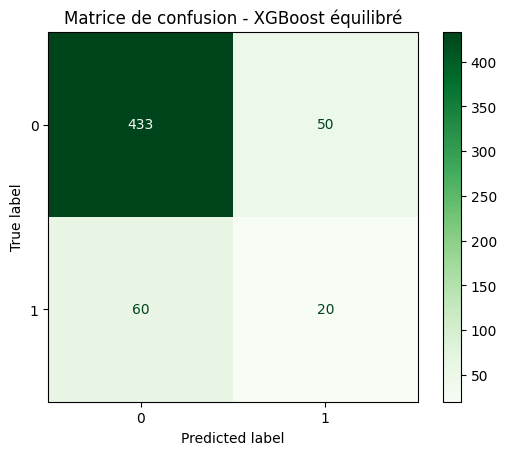

In [74]:
# scale_pos_weight = nb non fatal / nb fatal
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight : {scale:.2f}")

xgb_balanced = XGBClassifier(
    random_state=0,
    eval_metric="logloss",
    scale_pos_weight=scale
)
xgb_balanced.fit(X_train_pca, y_train)

y_pred_xgb_balanced = xgb_balanced.predict(X_test_pca)

print("\nXGBoost équilibré - Résultats")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb_balanced))
print(classification_report(y_test, y_pred_xgb_balanced, target_names=["Non Fatal", "Fatal"]))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb_balanced, cmap="Greens")
plt.title("Matrice de confusion - XGBoost équilibré")
plt.show()

### 📌 Ce que j'observe

| Modèle | Accuracy | Recall Fatal | F1 Fatal |
|---|---|---|---|
| Régression Logistique | 0.87 | 0.05 | 0.10 |
| Random Forest (Halving) | 0.86 | 0.11 | 0.18 |
| XGBoost | 0.84 | 0.16 | 0.23 |
| **XGBoost équilibré** | **0.80** | **0.25** | **0.27** |

<br>

> 🎉 Le recall Fatal passe de **0.16 à 0.25** — je détecte 25% des attaques fatales !
> `scale_pos_weight = 6.03` : les attaques fatales sont **6 fois plus rares**
> — mon modèle en tient maintenant compte.

## 🔵 18. K-Means Clustering

Le **K-Means** est un modèle non supervisé : il n'a pas de cible à prédire.
Il découvre lui-même des groupes dans les données.

Je vais identifier des **profils types de victimes**.

Je dois d'abord trouver le bon nombre de clusters avec :
- **Elbow Method** : je cherche le coude dans la courbe
- **Coefficient de Silhouette** : mesure si les clusters sont bien séparés

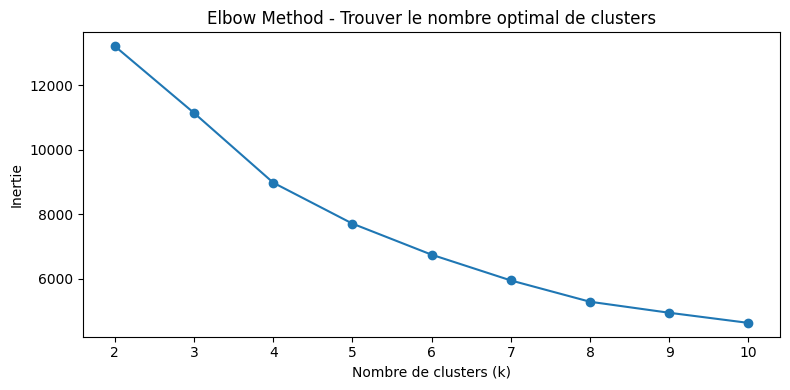

In [75]:
# Elbow Method : je teste de 2 à 10 clusters
inerties = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(X_train_pca)
    inerties.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(2, 11), inerties, marker='o')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Elbow Method - Trouver le nombre optimal de clusters')
plt.tight_layout()
plt.show()

### 📌 Ce que j'observe

La courbe descend régulièrement sans coude très prononcé.
Je distingue un léger changement de pente autour de **k=4**.

> 💡 Je vais confirmer ça avec le Coefficient de Silhouette !

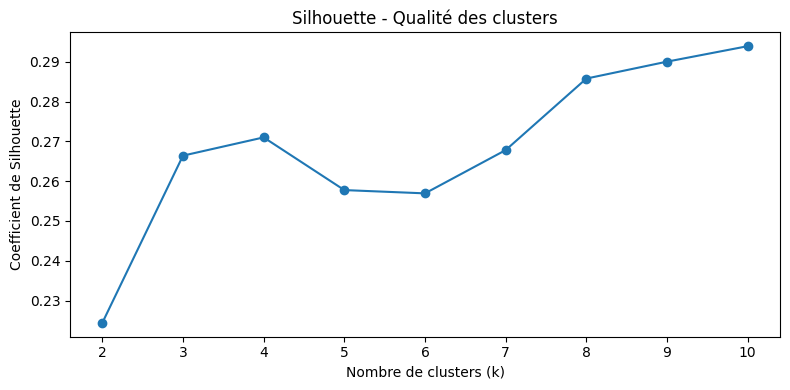

In [76]:
# Coefficient de Silhouette : mesure la qualité des clusters
silhouettes = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = kmeans.fit_predict(X_train_pca)
    silhouettes.append(silhouette_score(X_train_pca, labels))

plt.figure(figsize=(8, 4))
plt.plot(range(2, 11), silhouettes, marker='o')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Coefficient de Silhouette')
plt.title('Silhouette - Qualité des clusters')
plt.tight_layout()
plt.show()

### 📌 Ce que j'observe

Le score Silhouette montre un **premier pic à k=4** avant la chute.

> 💡 Je choisis **k=4** car :
> - C'est le premier pic local du score Silhouette
> - Cohérent avec le coude de l'Elbow Method
> - 4 clusters = 4 profils de victimes interprétables

In [77]:
# Entraînement du K-Means final avec k=4
kmeans_final = KMeans(n_clusters=4, random_state=0, n_init=10)
kmeans_final.fit(X_train_pca)

labels = kmeans_final.labels_
print("Répartition des données par cluster :")
for k in range(4):
    print(f"  Cluster {k} : {(labels == k).sum()} points")

Répartition des données par cluster :
  Cluster 0 : 690 points
  Cluster 1 : 1294 points
  Cluster 2 : 23 points
  Cluster 3 : 241 points


### 📌 Ce que j'observe

| Cluster | Taille | Interprétation probable |
|---|---|---|
| Cluster 0 | ~690 points | Groupe moyen — profil standard |
| Cluster 1 | ~1294 points | Groupe majoritaire — le plus commun |
| Cluster 2 | ~23 points | Groupe rare — cas atypiques |
| Cluster 3 | ~241 points | Groupe minoritaire — profil spécifique |

<br>

> 💡 Le **Cluster 2** avec seulement ~23 points représente probablement
> des cas **très atypiques** — attaques dans des zones inhabituelles ou espèces rares.

> 🔍 Le **Cluster 1** regroupe la majorité des victimes —
> probablement les surfeurs et baigneurs aux USA et en Australie.

## 📋 19. Conclusion

### 🏆 Comparaison des modèles

| Modèle | Accuracy | Recall Fatal | F1 Fatal |
|---|---|---|---|
| Régression Logistique | 0.87 | 0.05 | 0.10 |
| Random Forest (GridSearch) | 0.86 | 0.09 | 0.15 |
| Random Forest (Randomized Search) | 0.86 | 0.09 | 0.15 |
| Random Forest (Halving) | 0.86 | 0.11 | 0.18 |
| XGBoost | 0.84 | 0.16 | 0.23 |
| **XGBoost équilibré** | **0.80** | **0.25** | **0.27** |

<br>

**Mon meilleur modèle est XGBoost équilibré** — il détecte 25% des attaques fatales
contre seulement 5% pour la régression logistique.

---

### 🦈 Ce que j'ai appris

- 🌍 Les **USA et l'Australie** concentrent la majorité des attaques
- 🏄 Le **surf** est l'activité la plus dangereuse
- 👨 Les **hommes** sont 9x plus attaqués que les femmes
- 📈 Les attaques augmentent mais sont **de moins en moins mortelles**
- 🦈 Le **grand requin blanc** est l'espèce la plus impliquée

---

### 💑 Réponse à ma chérie

> *"To swim or not to swim ?"*

**Les statistiques parlent d'elles-mêmes :**
- ✅ 76% des attaques ne sont **pas fatales**
- ✅ Les femmes sont **9x moins attaquées** que les hommes
- ✅ Évite le **surf** aux **USA et en Australie**
- ✅ Les requins attaquent ~100 personnes par an dans le monde entier
  sur des **milliards de baignades** !

<br>

> 🌊 *Ma chérie peut y aller, les statistiques sont de son côté !* 😄
>
> 🦈 *...mais bon, je comprends quand même qu'elle préfère rester sur la plage* 😅